In [5]:
# load in the packages you will need for your analysis

import pandas as pd  # pandas is a package for data analysis and manipulation
import seaborn as sns  # seaborn is a data visualization package
import matplotlib.pyplot as plt # matplotlib is the OG python plotting library and really useful for formatting  

Dataset contains cumulative counts of debris that has been collected from Norfolk beaches. The cleanup takes place every September and October and the dataset is updated annually. This dataset represents Norfolk's local contribution to the global International Coastal Cleanup dataset.

In [6]:
# load in the csv file with coastal clean up data 

# set the path to the correct directory for your particular computer
infile = r'C:\Users\joann\OEAS805\HW2\International_Coastal_Cleanup.csv'

# read in the .csv file with the column separator explicitly defined
data = pd.read_csv(infile, sep = ',' , low_memory = False)

In [7]:
# print the information about the data in the dataframe
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 53 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Area                                       77 non-null     str    
 1   Date                                       77 non-null     str    
 2   Cigarette Butts                            77 non-null     str    
 3   Food Wrappers (candy, chips, etc.)         77 non-null     str    
 4   Take Out/Away Containers (Plastic)         77 non-null     int64  
 5   Take Out/Away Containers (Foam)            77 non-null     int64  
 6   Bottle Caps (Plastic)                      77 non-null     int64  
 7   Bottle Caps (Metal)                        77 non-null     str    
 8   Lids (Plastic)                             77 non-null     int64  
 9   Straws, Stirrers                           77 non-null     int64  
 10  Forks, Knives, Spoons                  

Dataset contains a combination of variable types: string (texts/words), integer (whole numbers), floating-point number (numbers with decimal places). 

Some columns are reading as text instead of numbers. The code below fixes that.

In [8]:
# List of columns that should be numbers but are currently stored as strings (text)
cols_to_fix = [
    'Cigarette Butts', 
    'Food Wrappers (candy, chips, etc.)', 
    'Bottle Caps (Metal)', 
    'Beverage Bottles (Glass)', 
    'Personal Hygiene (Clean Swell)', 
    'Glass Pieces', 
    'Plastic Pieces', 
    'Total Items Collected', 
    'Total Pounds of Litter Collected'
]

# Clean commas and convert to numeric values
for col in cols_to_fix:
    # Remove commas if any exist, then convert to numbers
    data[col] = pd.to_numeric(data[col].astype(str).str.replace(',', ''), errors='coerce')

In [9]:
# the shape of the data
# nrows, ncols

data.shape

(77, 53)

Dataset contains 77 rows of different beaches/ clean up locations and 53 columns of different types of debris.

In [10]:
# total number of datapoints in the dataframe
# ncol * nrows

data.size

4081

Dataset contains 4081 datapoints total.

In [11]:
# gives a list of the column names in the dataframe

data.columns

Index(['Area', 'Date', 'Cigarette Butts', 'Food Wrappers (candy, chips, etc.)',
       'Take Out/Away Containers (Plastic)', 'Take Out/Away Containers (Foam)',
       'Bottle Caps (Plastic)', 'Bottle Caps (Metal)', 'Lids (Plastic)',
       'Straws, Stirrers', 'Forks, Knives, Spoons',
       'Beverage Bottles (Plastic)', 'Beverage Bottles (Glass)',
       'Beverage Cans', 'Grocery Bags (Plastic)', 'Other Plastic Bags',
       'Paper Bags', 'Cups, Plates (Paper)', 'Cups, Plates (Plastic)',
       'Cups, Plates (Foam)', 'Fishing Buoys, Pots & Traps',
       'Fishing Net & Pieces', 'Fishing Line (1 yard/meter = 1 piece)',
       'Rope (1 yard/meter = 1 piece)', 'Fishing Gear (Clean Swell)',
       '6-Pack Holders', 'Other Plastic/Foam Packaging',
       'Other Plastic Bottles (oil, bleach, etc.)', 'Strapping Bands',
       'Tobacco Packaging/Wrap', 'Other Packaging (Clean Swell)',
       'Appliances (refrigerators, washers, etc.)', 'Balloons', 'Cigar Tips',
       'Cigarette Lighters', 'Co

Columns do not only include different types of debris but also total counts and volunteer info.

In [12]:
data.isna().sum()

Area                                         0
Date                                         0
Cigarette Butts                              0
Food Wrappers (candy, chips, etc.)           0
Take Out/Away Containers (Plastic)           0
Take Out/Away Containers (Foam)              0
Bottle Caps (Plastic)                        0
Bottle Caps (Metal)                          0
Lids (Plastic)                               0
Straws, Stirrers                             0
Forks, Knives, Spoons                        0
Beverage Bottles (Plastic)                   0
Beverage Bottles (Glass)                     0
Beverage Cans                                0
Grocery Bags (Plastic)                       0
Other Plastic Bags                           0
Paper Bags                                   0
Cups, Plates (Paper)                         0
Cups, Plates (Plastic)                       0
Cups, Plates (Foam)                          0
Fishing Buoys, Pots & Traps                  0
Fishing Net &

Data columns do not contain missing data. All columns have 0 missing data points.

In [13]:
# descriptive statistics for the numeric data in the dataframe

pd.set_option('display.max_columns', None)
data.describe()

,Cigarette Butts,"Food Wrappers (candy, chips, etc.)",Take Out/Away Containers (Plastic),Take Out/Away Containers (Foam),Bottle Caps (Plastic),Bottle Caps (Metal),Lids (Plastic),"Straws, Stirrers","Forks, Knives, Spoons",Beverage Bottles (Plastic),Beverage Bottles (Glass),Beverage Cans,Grocery Bags (Plastic),Other Plastic Bags,Paper Bags,"Cups, Plates (Paper)","Cups, Plates (Plastic)","Cups, Plates (Foam)","Fishing Buoys, Pots & Traps",Fishing Net & Pieces,Fishing Line (1 yard/meter = 1 piece),Rope (1 yard/meter = 1 piece),Fishing Gear (Clean Swell),6-Pack Holders,Other Plastic/Foam Packaging,"Other Plastic Bottles (oil, bleach, etc.)",Strapping Bands,Tobacco Packaging/Wrap,Other Packaging (Clean Swell),"Appliances (refrigerators, washers, etc.)",Balloons,Cigar Tips,Cigarette Lighters,Construction Materials,Fireworks,Tires,Toys,Other Trash (Clean Swell),Condoms,Diapers,Syringes,Tampons/Tampon Applicators,Personal Hygiene (Clean Swell),Foam Pieces,Glass Pieces,Plastic Pieces,Total Items Collected,Total Pounds of Litter Collected,Number of Volunteers,Volunteer Hours,Number of Miles
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.00000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.00000,77.000000
mean,480.194805,154.220779,18.363636,13.714286,98.337662,245.376623,23.350649,50.558442,13.909091,68.922078,44.987013,44.350649,38.961039,36.233766,15.116883,21.285714,19.376623,19.207792,0.636364,2.103896,4.779221,5.590909,0.558442,1.870130,27.909091,3.129870,4.493506,33.987013,2.714286,0.571429,5.571429,35.792208,3.740260,10.909091,1.272727,0.857143,0.168831,18.961039,1.909091,1.259740,0.61039,0.922078,39.116883,64.441558,119.558442,267.233766,2059.474026,200.558442,18.896104,37.37013,1.530909
std,832.501510,219.833108,21.944253,18.943724,148.793093,924.419064,26.738877,62.141920,20.238825,92.227089,143.478725,55.825331,59.709922,77.109269,32.100571,38.343275,27.973220,40.714454,1.700689,3.740196,12.906163,16.172330,2.643231,4.832322,48.928568,5.184366,7.849947,61.799015,13.069508,1.794939,9.255764,64.068290,7.831116,18.400645,4.204122,1.978265,0.864544,67.232989,4.205829,3.743073,1.94771,2.113654,239.313600,128.515767,359.613370,875.693753,3408.767664,379.650445,27.249135,57.04352,1.486711
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,50.000000,26.000000,3.000000,1.000000,16.000000,1.000000,6.000000,11.000000,1.000000,15.000000,3.000000,6.000000,5.000000,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,5.000000,337.000000,30.000000,5.000000,9.00000,1.000000
50%,140.000000,64.000000,8.000000,6.000000,43.000000,15.000000,13.000000,24.000000,7.000000,34.000000,13.000000,26.000000,17.000000,10.000000,0.000000,8.000000,10.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.000000,0.000000,1.000000,11.000000,0.000000,0.000000,1.000000,13.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,14.000000,12.000000,63.000000,851.000000,80.00

I added a line of code to display all of the columns containing data. On average, cigarette butts were collected the most (mean=480), but the standard deviation is rather large (std=832). This implies that cigarette butts were collected in both really small and large quantities. This may be in correlation to how many volunteers were at the event. I will do correlation statistics to determine if the number of volunteers, volunteer hours, or number of miles affects how many total items are collected at these events.

There was at least one event where 0 cigarette butts were collected, and there was one event where 3639 butts were collected. The median (50%) value is 140, meaning half of the clean ups collected less than this value and half collected more. The mean is much higher than this value, meaning the data is right skewed (positively skewed). This is likely due to a few massive clean up events that skews the average up, even though most clean ups likely collected a smaller amount of butts.

In [14]:
# correlations between the different numeric data columns in the dataframe

data.corr(numeric_only = True)

,Cigarette Butts,"Food Wrappers (candy, chips, etc.)",Take Out/Away Containers (Plastic),Take Out/Away Containers (Foam),Bottle Caps (Plastic),Bottle Caps (Metal),Lids (Plastic),"Straws, Stirrers","Forks, Knives, Spoons",Beverage Bottles (Plastic),Beverage Bottles (Glass),Beverage Cans,Grocery Bags (Plastic),Other Plastic Bags,Paper Bags,"Cups, Plates (Paper)","Cups, Plates (Plastic)","Cups, Plates (Foam)","Fishing Buoys, Pots & Traps",Fishing Net & Pieces,Fishing Line (1 yard/meter = 1 piece),Rope (1 yard/meter = 1 piece),Fishing Gear (Clean Swell),6-Pack Holders,Other Plastic/Foam Packaging,"Other Plastic Bottles (oil, bleach, etc.)",Strapping Bands,Tobacco Packaging/Wrap,Other Packaging (Clean Swell),"Appliances (refrigerators, washers, etc.)",Balloons,Cigar Tips,Cigarette Lighters,Construction Materials,Fireworks,Tires,Toys,Other Trash (Clean Swell),Condoms,Diapers,Syringes,Tampons/Tampon Applicators,Personal Hygiene (Clean Swell),Foam Pieces,Glass Pieces,Plastic Pieces,Total Items Collected,Total Pounds of Litter Collected,Number of Volunteers,Volunteer Hours,Number of Miles
Cigarette Butts,1.000000,0.571074,0.255237,0.339120,0.698723,0.609342,0.355483,0.665355,0.544626,0.364068,0.480398,0.486775,0.412236,0.515960,0.409545,0.378931,0.317717,0.472109,-0.060385,0.323815,0.201242,0.121124,-0.059277,0.087757,0.390664,0.270826,0.402685,0.524684,-0.050205,0.216002,0.528209,0.725017,0.510895,0.265139,0.499640,0.235530,0.248785,-0.002617,0.267052,0.343976,-0.033807,0.144687,0.022706,0.391853,0.528334,0.228574,0.740820,0.436084,0.466998,0.543612,0.070772
"Food Wrappers (candy, chips, etc.)",0.571074,1.000000,0.467730,0.676394,0.716299,0.725218,0.618879,0.692558,0.620260,0.713001,0.669338,0.720988,0.692161,0.758852,0.716835,0.663390,0.670045,0.743956,0.064024,0.495118,0.304751,0.331970,-0.102273,0.187282,0.613917,0.475956,0.633577,0.709800,-0.094314,0.565324,0.567226,0.778844,0.777146,0.521270,0.144525,0.627912,0.259352,0.233724,0.496876,0.190713,0.100969,0.407785,0.257176,0.623925,0.807933,0.486428,0.883929,0.628930,0.841800,0.821417,0.395803
Take Out/Away Containers (Plastic),0.255237,0.467730,1.000000,0.607496,0.356321,0.150825,0.700904,0.507858,0.370703,0.668326,0.286396,0.601108,0.545280,0.410773,0.497603,0.605606,0.608892,0.381699,0.158014,0.436229,0.223383,0.272229,0.030026,0.233602,0.414767,0.421494,0.564029,0.330811,0.085150,0.417233,0.323521,0.324151,0.367926,0.497543,0.151803,0.268847,-0.041424,0.271189,0.185698,0.167516,0.066776,0.375363,0.124749,0.447907,0.270914,0.229292,0.404370,0.262710,0.422706,0.388223,0.318016
Take Out/Away Containers (Foam),0.339120,0.676394,0.607496,1.000000,0.522715,0.497701,0.702081,0.426763,0.413820,0.826804,0.690850,0.790598,0.838231,0.809596,0.630228,0.735717,0.731303,0.813913,0.399833,0.528388,0.613582,0.352500,-0.008859,0.259751,0.524576,0.586526,0.475843,0.416413,0.003280,0.444844,0.355520,0.474373,0.653882,0.511592,0.187517,0.518531,-0.003443,0.117206,0.342349,0.207407,0.289366,0.260685,0.078633,0.648022,0.616848,0.251848,0.635792,0.606671,0.611088,0.699840,0.169156
Bottle Caps (Plastic),0.698723,0.716299,0.356321,0.522715,1.000000,0.711129,0.471438,0.763219,0.714716,0.541608,0.448545,0.502784,0.510702,0.552785,0.395124,0.386278,0.419845,0.579048,0.071416,0.376693,0.218092,0.225904,-0.047324,0.180315,0.544539,0.445698,0.441663,0.820020,-0.025878,0.257623,0.577587,0.759903,0.540398,0.420418,0.353143,0.482358,0.439995,0.020179,0.390141,0.330900,0.052537,0.201953,0.163837,0.465964,0.527321,0.375001,0.792166,0.475507,0.590190,0.629001,0.137659
Bottle Caps (Metal),0.609342,0.725218,0.150825,0.497701,0.711129,1.000000,0.347523,0.532873,0.559719,0.422048,0.789906,0.480218,0.556508,0.697791,0.371281,0.347193,0.308657,0.742141,-0.012834,0.122540,0.281619,0.020991,-0.056818,0.145873,0.375164,0.227930,0.346452,0.689437,-0.055852,0.254268,0.610612,0.794036,0.794219,0.169868,0.188723,0.322367,0.446731,-0.055619,0.304570,0.233745,-0.026365,-0.052693,0.062788,0.382773,0.789674,0.240316,0.818356,0.673

Cigarette butts were moderately correlated with number of volunteers and volunteer hours and were poorly correlated with number of miles, which is opposite of what I predicted due to the large std. Total items collected were positively correlated with number of volunteers and volunteer hours, but also poorly correlated with the number of miles. This implies that more volunteer effort does drive higher overall item collection, but distance covered is not a good predictor of debris density.  

In [15]:
# get a list of the unique values found in the 'Area' column of the dataframe
data['Area'].unique()

# assign the list of unique values of 'Area' to a new variable called 'areas'
areas = data['Area'].unique()

# count the number of unique cleanup areas 
len(areas)

36

There are 36 unique cleanup areas. 

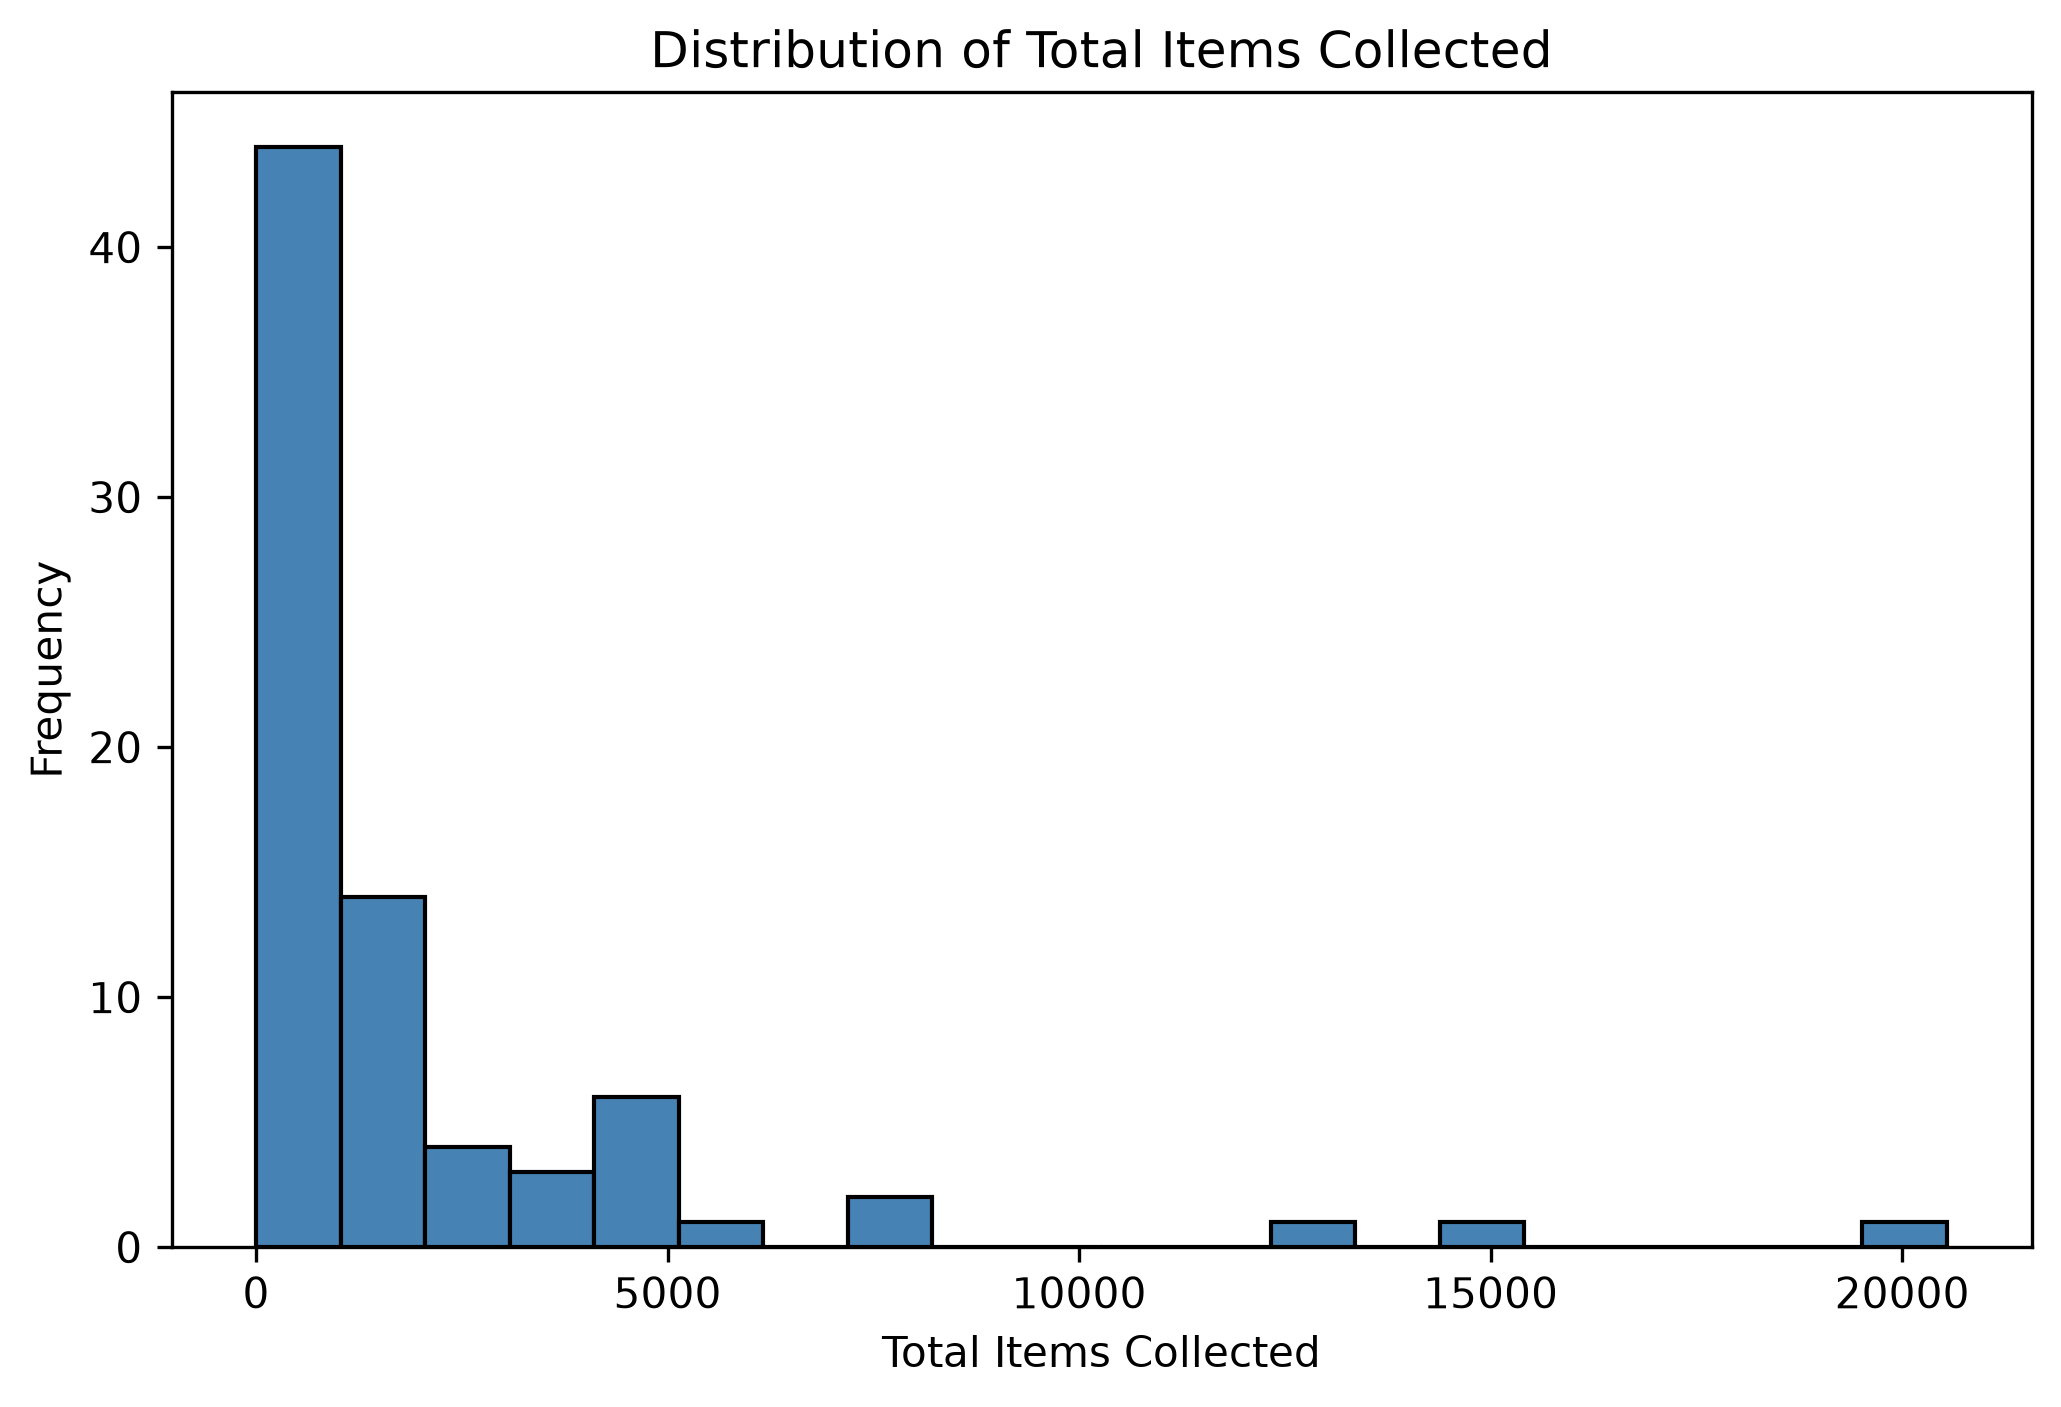

In [16]:
# histogram of total items collected 
fig, ax = plt.subplots(1, figsize = (8,5), dpi = 300)
plt.hist(data['Total Items Collected'].dropna(), bins=20, color="steelblue", edgecolor="black")
plt.title("Distribution of Total Items Collected")
plt.xlabel("Total Items Collected")
plt.ylabel("Frequency")
plt.show()

Most clean up events collected 5000 items or fewer. There was a major clean up event that collected 20000 items, however this is likely an outlier. This is a skewed distribution, and I will make a box plot to analyze outliers.

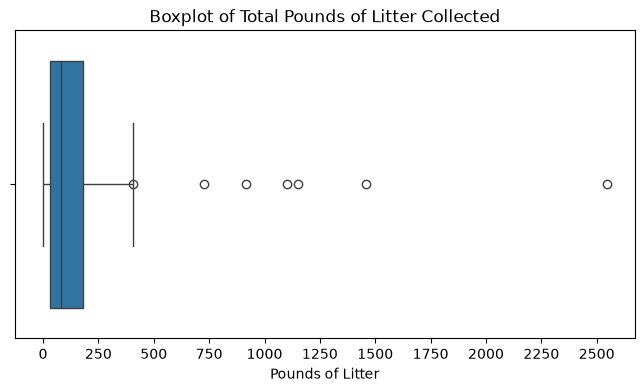

In [25]:
# boxplot to inspect extreme values in pounds of litter collected
plt.figure(figsize=(8, 4))
sns.boxplot(x=data['Total Pounds of Litter Collected'])
plt.title('Boxplot of Total Pounds of Litter Collected')
plt.xlabel('Pounds of Litter')
plt.xticks(range(0,2750,250))
plt.show()

The boxplot demonstrates a right skewed distribution. The median lies at 80 pounds of litter but one cleanup event collected over 2500 pounds of litter. The box represents the middle 50% of all cleanup events, meaning 50% collected 30-80 pounds of litter. 6 clean up events were extreme, non-typical events (outliers). 

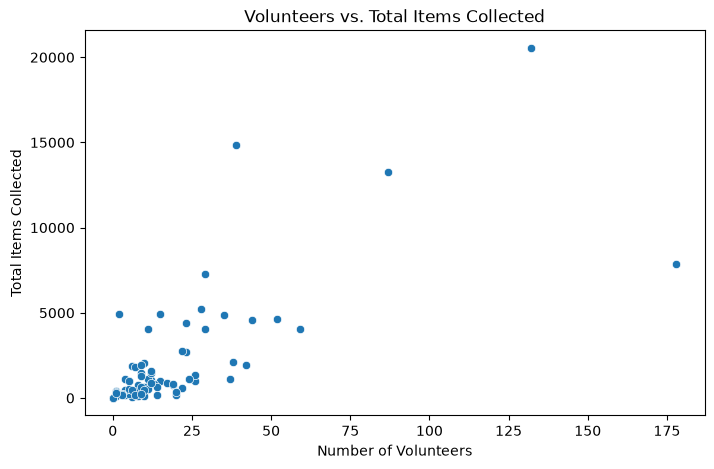

In [18]:
# check relationship between Number of Volunteers and Total Items Collected
plt.figure(figsize=(8, 5))
sns.scatterplot(x=data['Number of Volunteers'], y=data['Total Items Collected'])
plt.title('Volunteers vs. Total Items Collected')
plt.xlabel('Number of Volunteers')
plt.ylabel('Total Items Collected')
plt.show()

Total items collected positively correlate with the number of volunteers (r=0.73). The more volunteers there are, the more trash is generally collected. This is not true in all cases, like when there were over 175 volunteers but less than 10,000 pieces of trash collected. 

In [19]:
#find where area equals old dominion u
odu = data[data['Area'] == 'Old Dominion University']
odu.info

<bound method DataFrame.info of                        Area        Date  Cigarette Butts  \
26  Old Dominion University  09/20/2021               13   
35  Old Dominion University  10/05/2019              383   
43  Old Dominion University  10/13/2018               19   
59  Old Dominion University  09/30/2017               35   

    Food Wrappers (candy, chips, etc.)  Take Out/Away Containers (Plastic)  \
26                                  42                                   0   
35                                  60                                  20   
43                                  17                                   7   
59                                   9                                   0   

    Take Out/Away Containers (Foam)  Bottle Caps (Plastic)  \
26                                0                      9   
35                                1                     39   
43                                4                      6   
59                          

Trash was collected from ODU on 4 different occasions. I will sum up the different types of trash collected over the years and create a barplot to determine what ODU students and visitors litter the  most. 

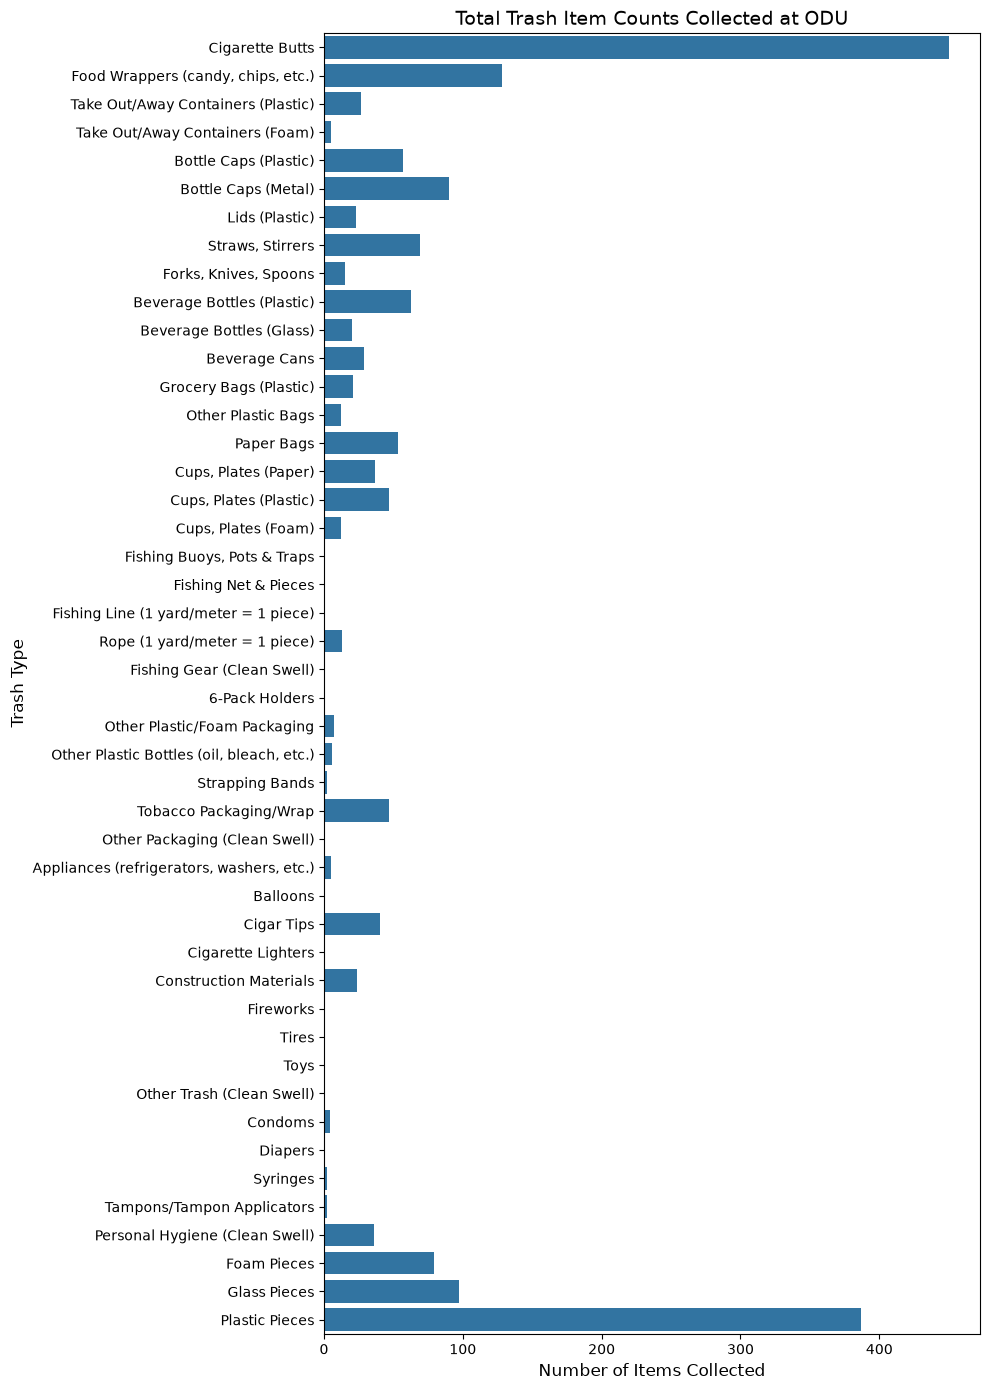

In [21]:
#trash item column names 
trash_types = list(data.columns[2:48])

#summing up total trash between years in each column
odu_trash = odu[trash_types].sum()

#making a bar plot with all trash types
plt.figure(figsize=(10,14))
sns.barplot(x=odu_trash.values, y=odu_trash.index, orient='h')
plt.title('Total Trash Item Counts Collected at ODU', fontsize=14)
plt.xlabel('Number of Items Collected', fontsize=12)
plt.ylabel('Trash Type', fontsize=12)
plt.tight_layout()
plt.show()

Cigarette butts were the most common trash item collected during the cleanup events at ODU, and plastic pieces were a close second. I am surprised that nothing fishing related (fishing traps, nets, lines, gear) was collected as litter at ODU, and that cigarette butts were the most common trash item, but no cigarette lighters were collected. How peculiar.

From my exploration of the data, I conclude that people are nasty and think the earth is a big giant trashcan, especially people who smoke cigarettes. People need to be more mindful that the world does not revolve around them and they do in fact co-exist with other people and living organisms. 